In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

ModuleNotFoundError: No module named 'numpy'

In [ ]:
def load_and_preprocess_data(data_path):
    # Carrega os dados
    df = pd.read_csv(data_path)
    
    # Remove a coluna ID se existir
    if 'id' in df.columns:
        df = df.drop('id', axis=1)
    
    # Separa features e target
    X = df.drop('diagnosis', axis=1)
    y = df['diagnosis'].map({'M': 1, 'B': 0})
    
    # Normalização
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Verifica e trata NaN
    if np.isnan(X_scaled).any():
        print("ATENÇÃO: NaN encontrados após normalização")
        X_scaled = np.nan_to_num(X_scaled, nan=0.0)
    
    # Converte para tensores
    X_tensor = torch.FloatTensor(X_scaled)
    y_tensor = torch.FloatTensor(y.values).reshape(-1, 1)
    
    return X_tensor, y_tensor

def prepare_data_loaders(X_tensor, y_tensor, batch_size=32, test_size=0.2):
    # Split treino/teste
    X_train, X_test, y_train, y_test = train_test_split(
        X_tensor, y_tensor, test_size=test_size, random_state=42, stratify=y_tensor
    )
    
    # Cria DataLoaders
    train_dataset = TensorDataset(X_train, y_train)
    test_dataset = TensorDataset(X_test, y_test)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    return train_loader, test_loader, X_train, X_test, y_train, y_test

In [ ]:
class NeuralNetwork(nn.Module):
    def __init__(self, input_size, hidden_sizes, dropout_rate=0.2):
        super().__init__()
        
        layers = []
        prev_size = input_size
        
        for hidden_size in hidden_sizes:
            layers.extend([
                nn.Linear(prev_size, hidden_size),
                nn.BatchNorm1d(hidden_size),
                nn.ReLU(),
                nn.Dropout(dropout_rate)
            ])
            prev_size = hidden_size
        
        layers.extend([
            nn.Linear(prev_size, 1),
            nn.Sigmoid()
        ])
        
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x)

In [ ]:
def train_model(model, train_loader, test_loader, optimizer, criterion, n_epochs, device='cpu'):
    history = {'loss': [], 'val_loss': []}
    
    model = model.to(device)
    
    for epoch in range(n_epochs):
        model.train()
        train_loss = 0
        
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            
            optimizer.zero_grad()
            y_pred = model(X_batch)
            
            if torch.isnan(y_pred).any():
                print(f"NaN encontrado nas previsões - Época {epoch}")
                continue
                
            loss = criterion(y_pred, y_batch)
            
            if torch.isnan(loss).any():
                print(f"NaN encontrado na loss - Época {epoch}")
                continue
                
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            train_loss += loss.item()
        
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)
                y_pred = model(X_batch)
                val_loss += criterion(y_pred, y_batch).item()
        
        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss = val_loss / len(test_loader)
        history['loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        
        if epoch % 10 == 0:
            print(f"Época {epoch} — Loss treino: {avg_train_loss:.4f} | Loss val: {avg_val_loss:.4f}")
    
    return history

/home/jx/Documentos/dev/uerj/redes-neurais/breast-cancer-neural-networks/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/home/jx/Documentos/dev/uerj/redes-neurais/breast-cancer-neural-networks/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/home/jx/Documentos/dev/uerj/redes-neurais/breast-cancer-neural-networks/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


ATENÇÃO: NaN encontrados após normalização
Época 0 — Loss treino: 0.6149 | Loss val: 0.5729
Época 10 — Loss treino: 0.1748 | Loss val: 0.1413
Época 20 — Loss treino: 0.1025 | Loss val: 0.0838
Época 30 — Loss treino: 0.0776 | Loss val: 0.0897
Época 40 — Loss treino: 0.0673 | Loss val: 0.0874
Época 50 — Loss treino: 0.0838 | Loss val: 0.0871
Época 60 — Loss treino: 0.0799 | Loss val: 0.1123
Época 70 — Loss treino: 0.0547 | Loss val: 0.0926
Época 80 — Loss treino: 0.0621 | Loss val: 0.0849
Época 90 — Loss treino: 0.0559 | Loss val: 0.0806

Resultados:
Acurácia: 0.9649
Precisão: 1.0000
Recall: 0.9048
F1-score: 0.9500


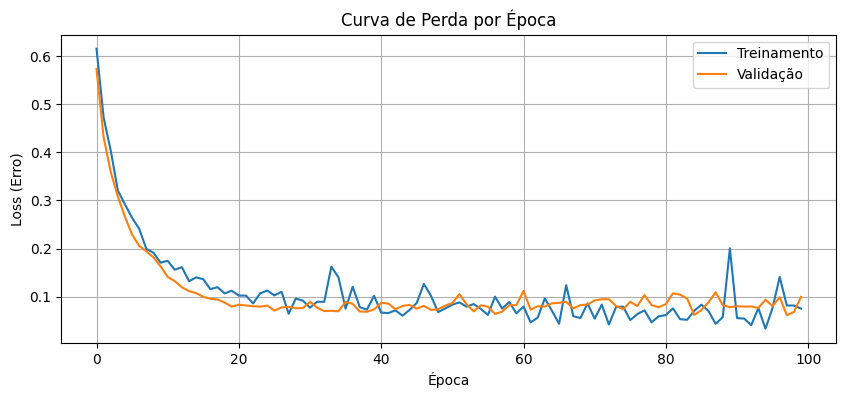

In [ ]:
# Configurações e hiperparâmetros
config = {
    'n_layers': 2,
    'n_neurons': 32,
    'learning_rate': 0.001,
    'batch_size': 32,
    'epochs': 100,
    'dropout_rate': 0.2
}

# Preparação dos dados
X_tensor, y_tensor = load_and_preprocess_data('../data/breast_cancer.csv')
train_loader, test_loader, X_train, X_test, y_train, y_test = prepare_data_loaders(
    X_tensor, y_tensor, batch_size=config['batch_size']
)

# Criação do modelo
input_size = X_train.shape[1]
hidden_sizes = [config['n_neurons']] * config['n_layers']
model = NeuralNetwork(input_size, hidden_sizes, config['dropout_rate'])

# Otimizador e função de perda
optimizer = optim.Adam(model.parameters(), lr=config['learning_rate'], weight_decay=1e-5)
criterion = nn.BCELoss()

# Treinamento
history = train_model(model, train_loader, test_loader, optimizer, criterion, config['epochs'])

# Avaliação
model.eval()
with torch.no_grad():
    y_pred = model(X_test)
    y_pred = (y_pred > 0.5).float()

acc = accuracy_score(y_test.cpu(), y_pred.cpu())
prec = precision_score(y_test.cpu(), y_pred.cpu(), zero_division=0)
rec = recall_score(y_test.cpu(), y_pred.cpu(), zero_division=0)
f1 = f1_score(y_test.cpu(), y_pred.cpu(), zero_division=0)

print(f"\nResultados:")
print(f"Acurácia: {acc:.4f}")
print(f"Precisão: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1-score: {f1:.4f}")

# Visualização da curva de aprendizado
plt.figure(figsize=(10, 4))
plt.plot(history['loss'], label='Treinamento')
plt.plot(history['val_loss'], label='Validação')
plt.title("Curva de Perda por Época")
plt.xlabel("Época")
plt.ylabel("Loss (Erro)")
plt.legend()
plt.grid(True)
plt.show()